In [1]:
# 导入第三方库
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error, r2_score
import torch
import shap

from torch.nn import init
import torch.nn as nn
import math

c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定义一个神经网络类
class StudyNet(torch.nn.Module):
    def __init__(self, in_size, h1_size, h2_size,  out_size):  # 定义初始化方法
        super(StudyNet, self).__init__()  # 继承
        self.h1 = torch.nn.Linear(in_size, h1_size)  # 隐藏层
        self.relu = torch.nn.ReLU()  # 激活函数
        self.h2 = torch.nn.Linear(h1_size, h2_size)  # 隐藏层
        
        self.out = torch.nn.Linear(h2_size, out_size)  # 输出层

    def forward(self, x):  # 定义前向传播方法
        h1_relu = self.relu(self.h1(x))  # 激活函数处理
        h2_relu = self.relu(self.h2(h1_relu))  # 激活函数处理
        
        predict = self.out(h2_relu)  # 通过线性函数输出
        return predict  # 返回预测值

In [ ]:
 # 读取数据
df = pd.read_excel('D:\桌面\ANN\Machine Learning date.xlsx',sheet_name="normalization")

# 用Pandas工具查看数据
print(df.head())

# 查看数据集摘要
print(df.info())

# 数据描述性统计分析
print(df.describe())


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\monk\AppData\Local\Temp\ipykernel_24412\1902964200.py:2: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_excel('D:\桌面\ANN\ML-V2.xlsx',sheet_name="zong")


      TOTLE  SR-PP-PLA-film  SR-PP-PLA-injection  SR-PP-PLA-other  \
0  0.903877        0.097413             0.304098         0.029132   
1  0.642962        0.838918             0.255072         0.764728   
2  0.274910        0.225456             0.035476         0.439970   
3  0.281879        0.646420             0.423909         0.050051   
4  0.472059        0.124321             0.977326         0.764407   

   SR-PP-PLA-fiber  SR-PP-PHA-injection  SR-PP-PHA-woven-goods  \
0         0.868000             0.050505               0.225763   
1         0.882615             0.349910               0.982172   
2         0.447775             0.751509               0.893427   
3         0.823260             0.023304               0.824497   
4         0.772144             0.858308               0.746359   

   SR-PP-PBS-film  SR-PP-PBS-injection  SR-PP-TPS-film  ...   CEI-PET  \
0        0.968943             0.425595        0.291814  ...  0.998912   
1        0.291358             0.834358    

C:\Users\monk\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\monk\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\monk\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\monk\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\monk\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170:

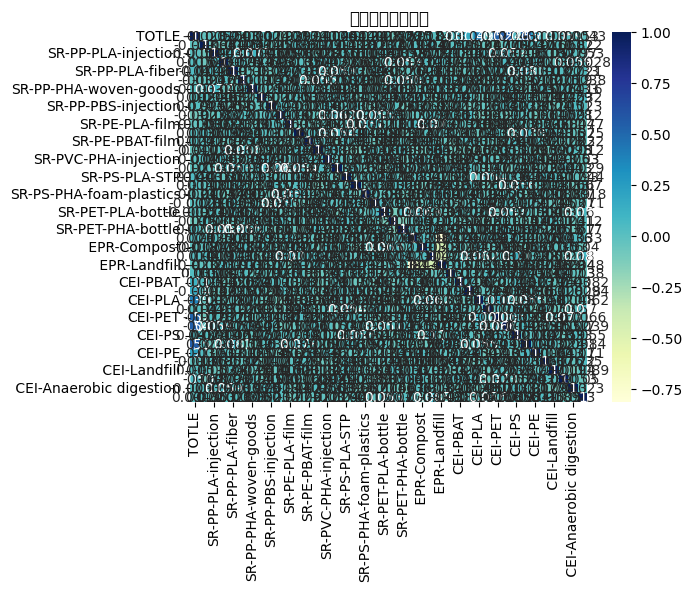

epoch:0,Train Loss:0.045947,Mean:0.15,Min:-0.07,Max:0.40,Median:0.15,Dealed/Records:128/800
epoch:0,Train Loss:0.013914,Mean:0.56,Min:0.30,Max:0.84,Median:0.56,Dealed/Records:256/800
epoch:0,Train Loss:0.029846,Mean:0.87,Min:0.57,Max:1.15,Median:0.87,Dealed/Records:384/800
epoch:0,Train Loss:0.032214,Mean:0.91,Min:0.63,Max:1.22,Median:0.91,Dealed/Records:512/800
epoch:0,Train Loss:0.026447,Mean:0.84,Min:0.58,Max:1.05,Median:0.83,Dealed/Records:640/800
epoch:0,Train Loss:0.017829,Mean:0.72,Min:0.45,Max:0.95,Median:0.72,Dealed/Records:768/800
epoch:0,Train Loss:0.011949,Mean:0.61,Min:0.44,Max:0.74,Median:0.62,Dealed/Records:896/800
epoch:1,Train Loss:0.017305,Mean:0.52,Min:0.30,Max:0.73,Median:0.52,Dealed/Records:128/800
epoch:1,Train Loss:0.018107,Mean:0.45,Min:0.19,Max:0.67,Median:0.46,Dealed/Records:256/800
epoch:1,Train Loss:0.020643,Mean:0.44,Min:0.17,Max:0.63,Median:0.43,Dealed/Records:384/800
epoch:1,Train Loss:0.018211,Mean:0.44,Min:0.25,Max:0.66,Median:0.44,Dealed/Records:512/80

In [4]:
# 数据的相关性分析
import seaborn as sns

sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)  # 绘制热力图
plt.title('相关性分析热力图')
plt.show()

    # 提取特征变量和标签变量
y = df['TOTLE']
X = df.drop('TOTLE', axis=1)

    # 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 定义批大小
batch_size = 128
    # 定义训练epoch
epoch = 100
    # 定义模型
model = StudyNet(41, 350, 100, 1)
    # 初始化权重参数(28:有几个X45是几、350第一层隐藏层大小、100：第二层隐藏层大小、1：输出层大小)
for layer in model.modules():
        if isinstance(layer, nn.Linear):
            init.xavier_uniform_(layer.weight)
    # 定义优化器
optimizer = torch.optim.Adam(model.parameters(), 0.001)
    # 定义损失函数
criterion = torch.nn.MSELoss()
    # 定义损失数组，用于可视化训练过程
loss_holder = []
    # 一个epoch可运行多少个Batch
blocks = math.ceil(y_train.count() / batch_size)
    # 损失值设置为无限大，每次迭代若损失值比loss_value小则保存模型，并将最新的损失值赋给loss_value
loss_value = np.inf
step = 0
for i in range(epoch):  # 循环
        train_count = 0
        batchs = 0
        for j in range(blocks):  # 循环
            train_x_data = torch.Tensor(X_train.iloc[j * batch_size:(j + 1) * batch_size].values)  # 转为Tensor张量
            train_x_data.requires_grad = True  # 自动求导
            train_y_data = torch.Tensor(y_train.iloc[j * batch_size:(j + 1) * batch_size].values)  # 转为Tensor张量
            # 输出值
            out = model(train_x_data)  # 预测
            # 损失值
            loss = criterion(out.squeeze(1), train_y_data)  # squeeze的用法主要就是对数据的维度进行压缩或者解压。
            # 反向传播，先将梯度设置为0，否则该步的梯度会和前面已经计算的梯度累乘
            optimizer.zero_grad()  # 清空过往梯度
            loss.backward()  # 反向传播,计算当前梯度
            # 更新参数
            optimizer.step()  # 根据梯度更新网络参数
            # 记录误差
            print('epoch:{},Train Loss:{:.6f},Mean:{:.2f},Min:{:.2f},Max:{:.2f},Median:{:.2f},Dealed/Records:{}/{}'.
                  format(i, math.sqrt(loss / batch_size), out.mean(), out.min(), out.max(), out.median(),
                         (j + 1) * batch_size, y_train.count()))

            if j % 10 == 0:
                step += 1
                loss_holder.append([step, math.sqrt(loss / batch_size)])  # 损失放入列表

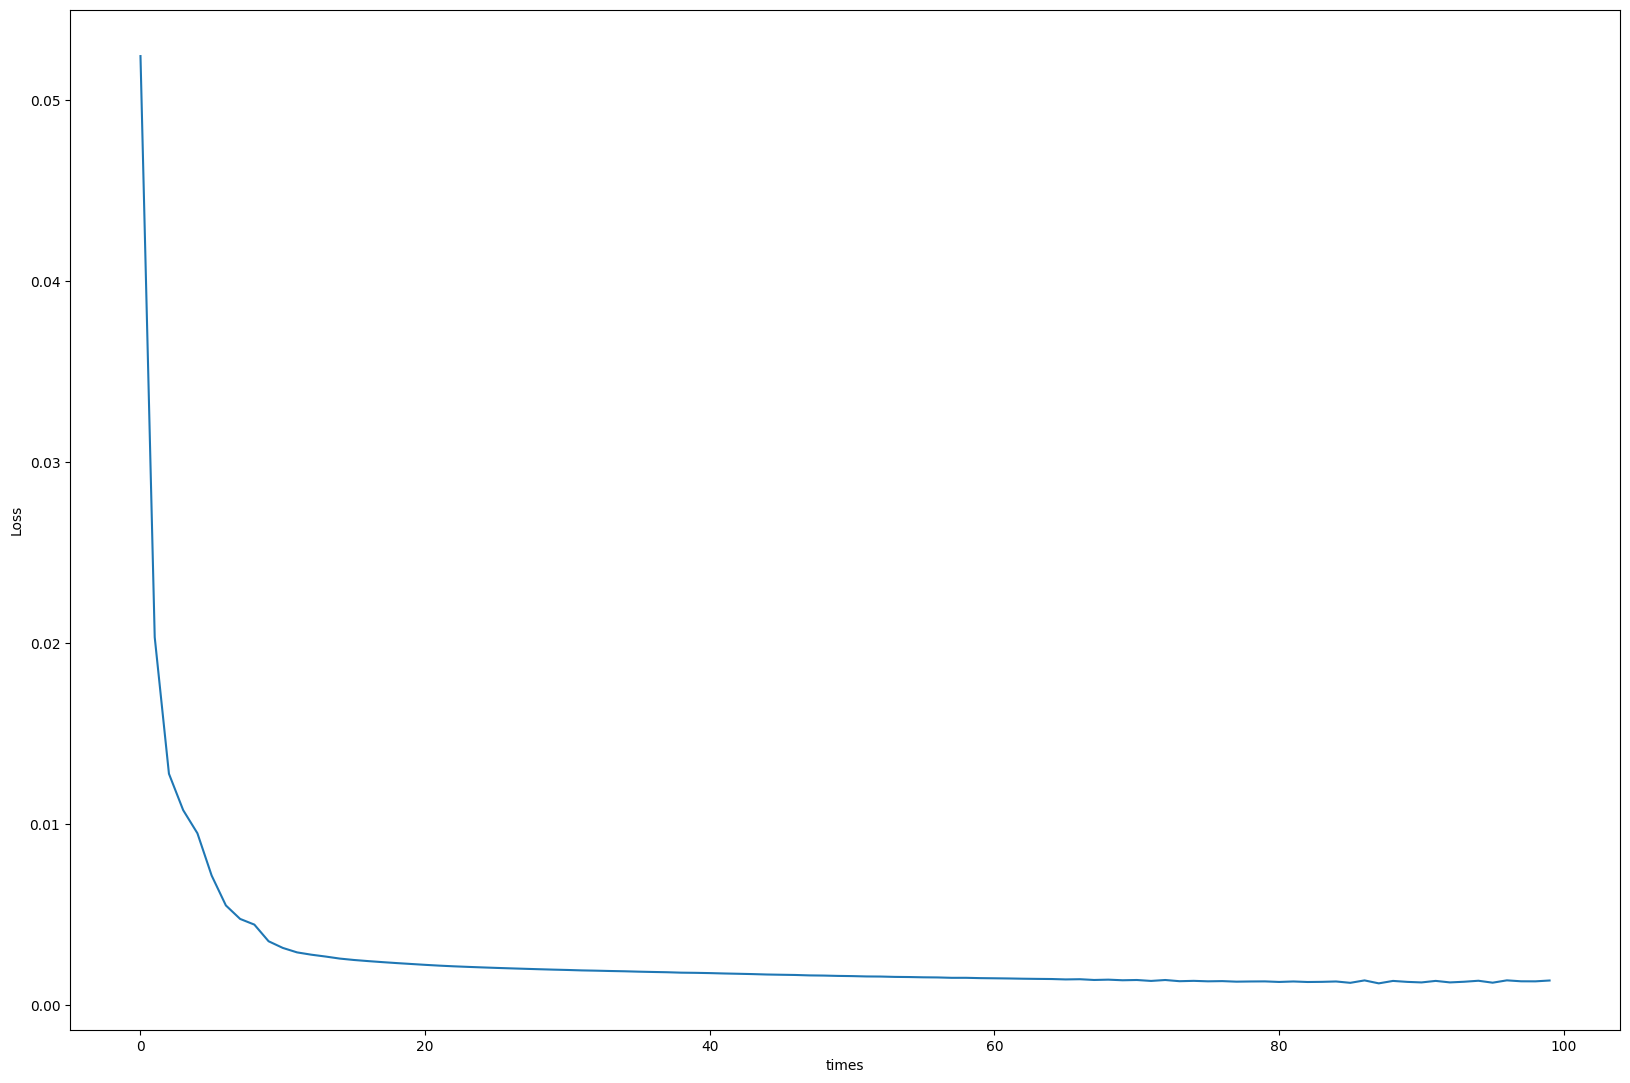

In [6]:
# 绘制损失曲线图
fig = plt.figure(figsize=(20, 15))
    # x轴字体倾斜避免重叠
fig.autofmt_xdate()
loss_df = pd.DataFrame(loss_holder, columns=['time', 'loss'])
x_times = loss_df['time'].values  # 迭代次数
plt.ylabel('Loss')  # 设置x轴名称
plt.xlabel('times')  # 设置y轴名称
plt.plot(loss_df['loss'].values)  # 折线图
plt.show()  # 显示图片

In [7]:
# 转化为测试模型
model.eval()  # 评估模式，而非训练模式。
for layer in model.modules():
        layer.requires_grad = False  # 不需要更新梯度
    # 损失函数
criterion = torch.nn.MSELoss()
results = []  # 定义列表
targets = []  # 定义列表
batches = math.ceil(y_test.count() / batch_size)  # 计算批次
for i in range(batches):  # 循环
        # 前向传播
        test_x_data = torch.Tensor(X_test.iloc[i * batch_size:(i + 1) * batch_size].values)  # 转为Tensor张量
        out = model(test_x_data)  # 进行测试集预测
        target = torch.Tensor(y_test.iloc[i * batch_size:(i + 1) * batch_size].values)  # 转为Tensor张量

        # 抽样用户可视化
        if i % 20 == 0:
            results.append(out.squeeze(1))  # 添加到列表
            targets.append(target)  # 添加到列表
        loss = criterion(out.squeeze(1), target)  # 计算损失

results_flatten = []
targets_flatten = []
    # detach()用于将当前的tensor从计算图中取出
[results_flatten.extend(result.detach().numpy().tolist()) for result in results]  # 展平列表
[targets_flatten.extend(target.detach().numpy().tolist()) for target in targets]  # 展平列表

[None]

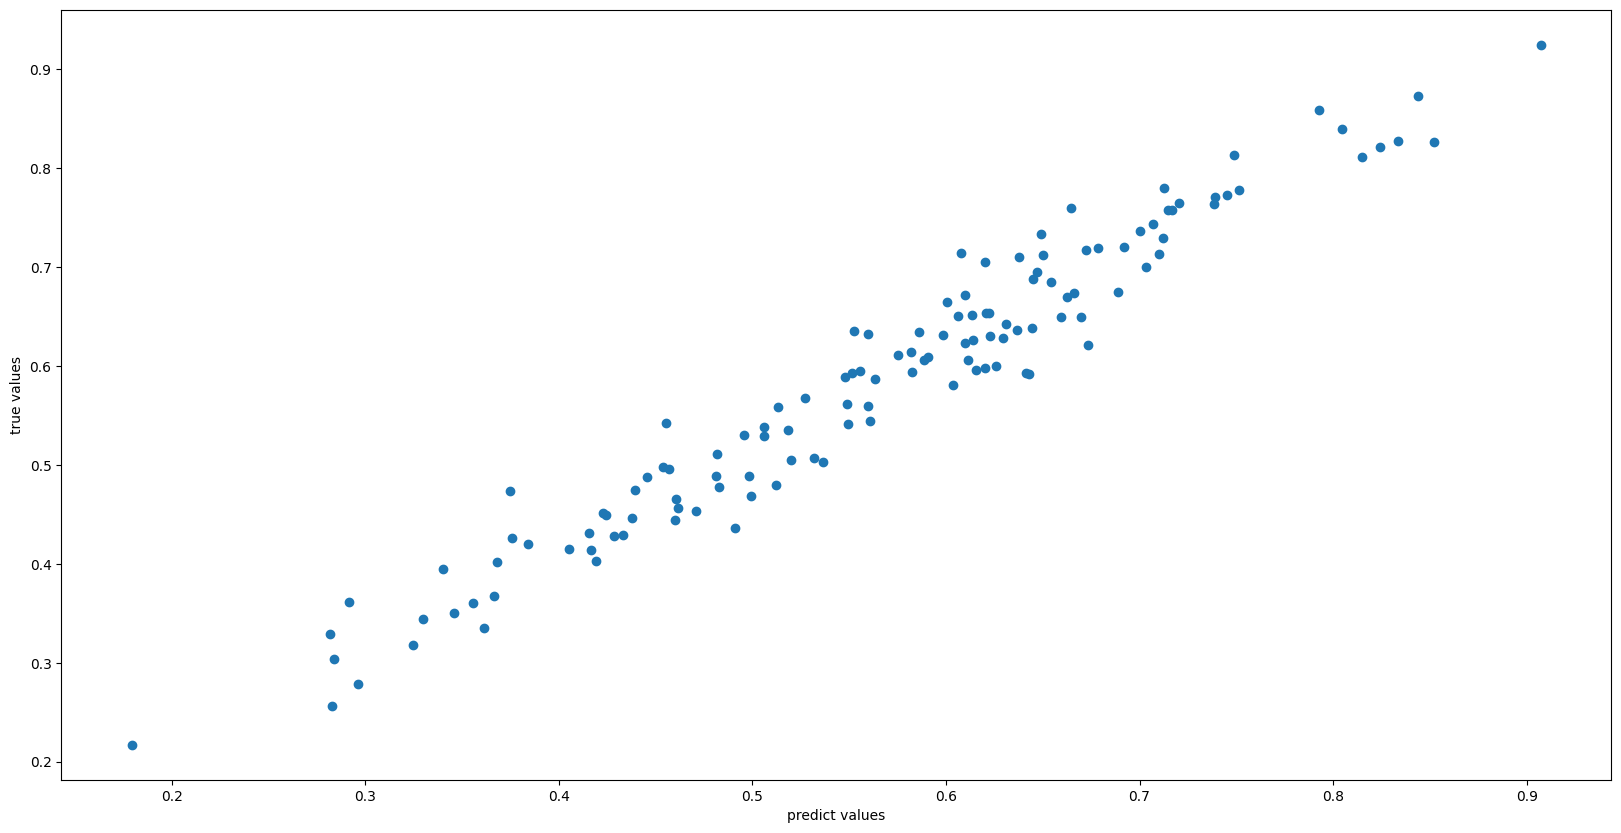

In [8]:
# 绘制预测值真实值散点图
plt.figure(figsize=(20, 10))  # 设置图片大小
plt.scatter(results_flatten, targets_flatten)  # 绘制散点图
plt.xlabel('predict values')  # 设置x轴的名称
plt.ylabel('true values')  # 设置y轴的名称
plt.show()  # 展示图片

In [9]:
print('----------------模型评估-----------------')
    # 模型评估
print('**************************输出测试集的模型评估指标结果*******************************')

print('PyTorch实现BP神经网络回归模型-最优参数-R^2：', round(r2_score(targets_flatten, results_flatten), 10))
print('PyTorch实现BP神经网络回归模型-最优参数-均方误差:', round(mean_squared_error(targets_flatten, results_flatten), 10))
print('PyTorch实现BP神经网络回归模型-最优参数-解释方差分:', round(explained_variance_score(targets_flatten, results_flatten), 10))
print('PyTorch实现BP神经网络回归模型-最优参数-绝对误差:', round(mean_absolute_error(targets_flatten, results_flatten), 10))

----------------模型评估-----------------
**************************输出测试集的模型评估指标结果*******************************
PyTorch实现BP神经网络回归模型-最优参数-R^2： 0.9302751335
PyTorch实现BP神经网络回归模型-最优参数-均方误差: 0.0014889746
PyTorch实现BP神经网络回归模型-最优参数-解释方差分: 0.9485070169
PyTorch实现BP神经网络回归模型-最优参数-绝对误差: 0.0308527354


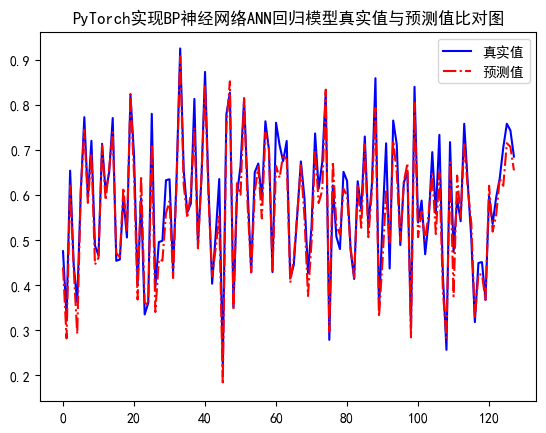

In [10]:
# 真实值与预测值比对图
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.plot(range(len(targets_flatten)), targets_flatten, color="blue", linewidth=1.5, linestyle="-")
plt.plot(range(len(results_flatten)), results_flatten, color="red", linewidth=1.5, linestyle="-.")
plt.legend(['真实值', '预测值'])
plt.title("PyTorch实现BP神经网络ANN回归模型真实值与预测值比对图")
plt.show()  # 显示图片

In [11]:
import shap
# 将模型转换为 SHAP 支持的形式
def model_predict(x):  # 定义预测函数
        x_tensor = torch.tensor(x, dtype=torch.float32)  # 转为张量类型
        with torch.no_grad():  # 设置位预测模式
            return model(x_tensor).numpy()  # 进行预测

    # 创建 SHAP 解释器
explainer = shap.KernelExplainer(model_predict, X_train[:100])

    # 计算 SHAP 值
shap_values1 = explainer.shap_values(X_test)
shap_values=np.squeeze(shap_values1, axis=-1)


100%|██████████| 200/200 [01:44<00:00,  1.91it/s]


In [12]:
print(np.array(shap_values).shape)
print(np.array(X_test).shape)

(200, 41)
(200, 41)


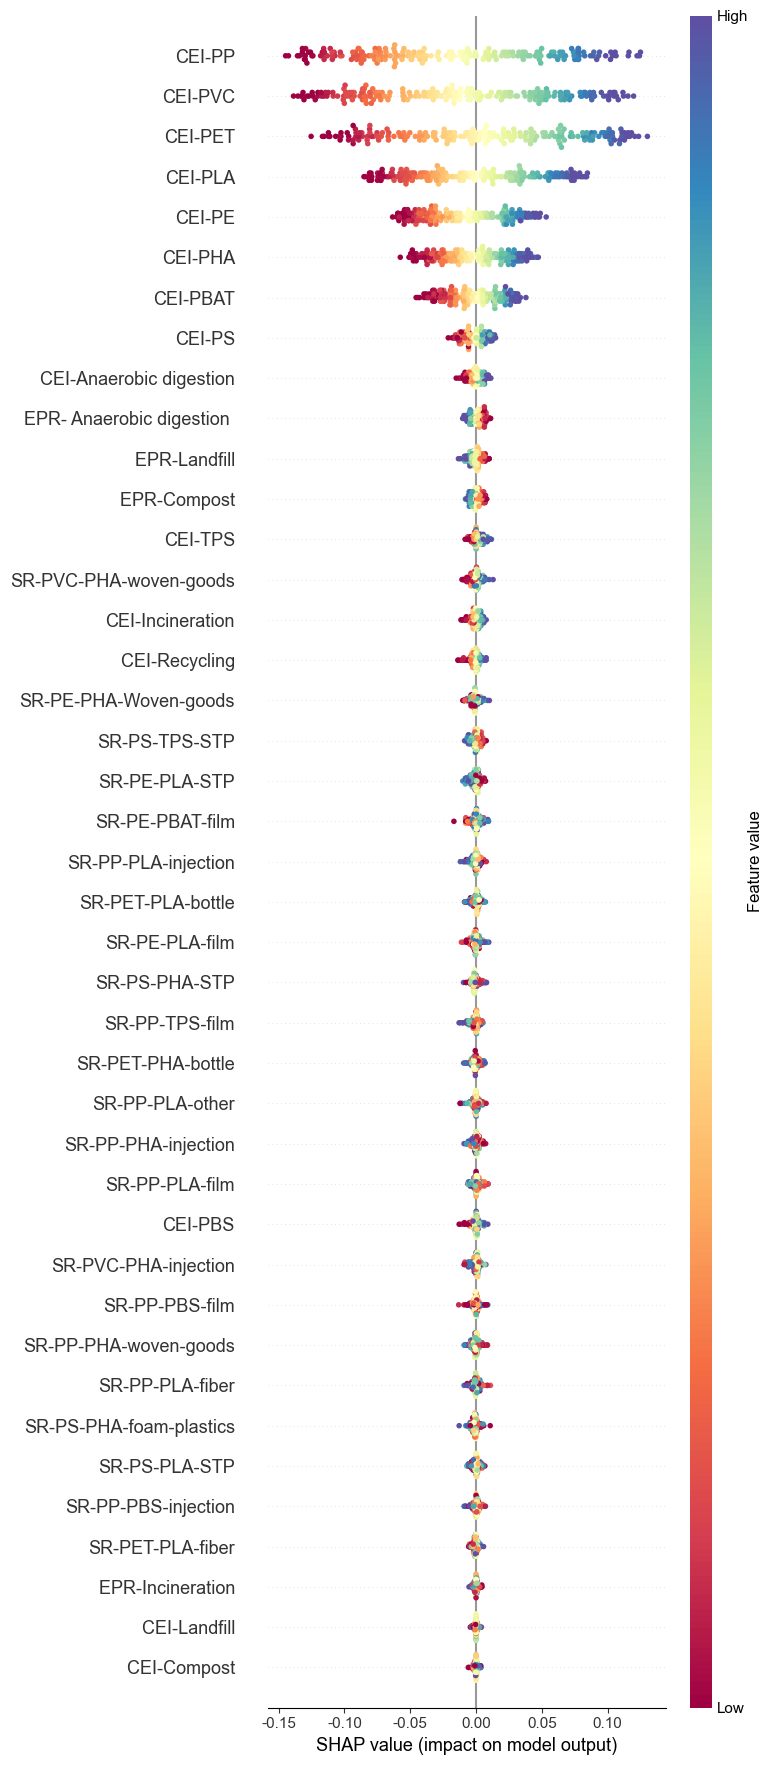

<Figure size 700x600 with 0 Axes>

In [14]:
feature_names = [ 'SR-PP-PLA-film', 'SR-PP-PLA-injection', 'SR-PP-PLA-other', 'SR-PP-PLA-fiber', 'SR-PP-PHA-injection', 'SR-PP-PHA-woven-goods', 'SR-PP-PBS-film', 'SR-PP-PBS-injection', 'SR-PP-TPS-film',
                 'SR-PE-PLA-film', 'SR-PE-PLA-STP', 'SR-PE-PBAT-film', 'SR-PE-PHA-Woven-goods', 'SR-PVC-PHA-injection', 'SR-PVC-PHA-woven-goods', 'SR-PS-PLA-STP',
                 'SR-PS-PHA-STP', 'SR-PS-PHA-foam-plastics', 'SR-PS-TPS-STP', 'SR-PET-PLA-bottle', 'SR-PET-PLA-fiber', 'SR-PET-PHA-bottle', ' EPR- Anaerobic digestion ', ' EPR-Compost', ' EPR-Incineration', ' EPR-Landfill', 'CEI-PBS', 'CEI-PBAT',
                 'CEI-PHA', 'CEI-PLA', 'CEI-TPS', 'CEI-PET', 'CEI-PP', 'CEI-PS', 'CEI-PVC', 'CEI-PE', ' CEI-Incineration', ' CEI-Landfill', ' CEI-Recycling', ' CEI-Anaerobic digestion', ' CEI-Compost'

]

#设置字体和大小
plt.rcParams['font.family']='serif'
plt.rcParams['font.serif']= 'Arial'
plt.rcParams['font.size']=15
plt.rcParams['text.color']="#000000"

# 配色有：viridis Spectral coolwarm RdYlGn RdYlBu RdBu RdGy PuOr BrBG PRGn PiYG
shap.summary_plot(shap_values, X_test,cmap='Spectral',max_display=50)


# 保存图形为高质量的图片文件
plt.gcf().set_size_inches(7,6)
plt.savefig('picture1.png',dpi=600,bbox_inches='tight')



In [13]:
import pandas as pd

# 假设 shap_values 是 NumPy 数组
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# 将特征值转换为DataFrame（如果X_test还不是DataFrame）
if not isinstance(X_test, pd.DataFrame):
    feature_df = pd.DataFrame(X_test, columns=X_test.columns)
else:
    feature_df = X_test.copy()

# 创建一个Excel写入对象
with pd.ExcelWriter('shap_analysis_results1.xlsx') as writer:
    # 保存SHAP值
    shap_df.to_excel(writer, sheet_name='SHAP Values', index=False)
    
    # 保存特征值
    feature_df.to_excel(writer, sheet_name='Feature Values', index=False)
    
    # 计算并保存特征重要性（SHAP绝对值均值）
    shap_importance = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_Mean_Abs': shap_df.abs().mean().values
    }).sort_values('SHAP_Mean_Abs', ascending=False)
    
    shap_importance.to_excel(writer, sheet_name='Feature Importance', index=False)

print("SHAP分析结果已成功导出到shap_analysis_results.xlsx")

SHAP分析结果已成功导出到shap_analysis_results.xlsx


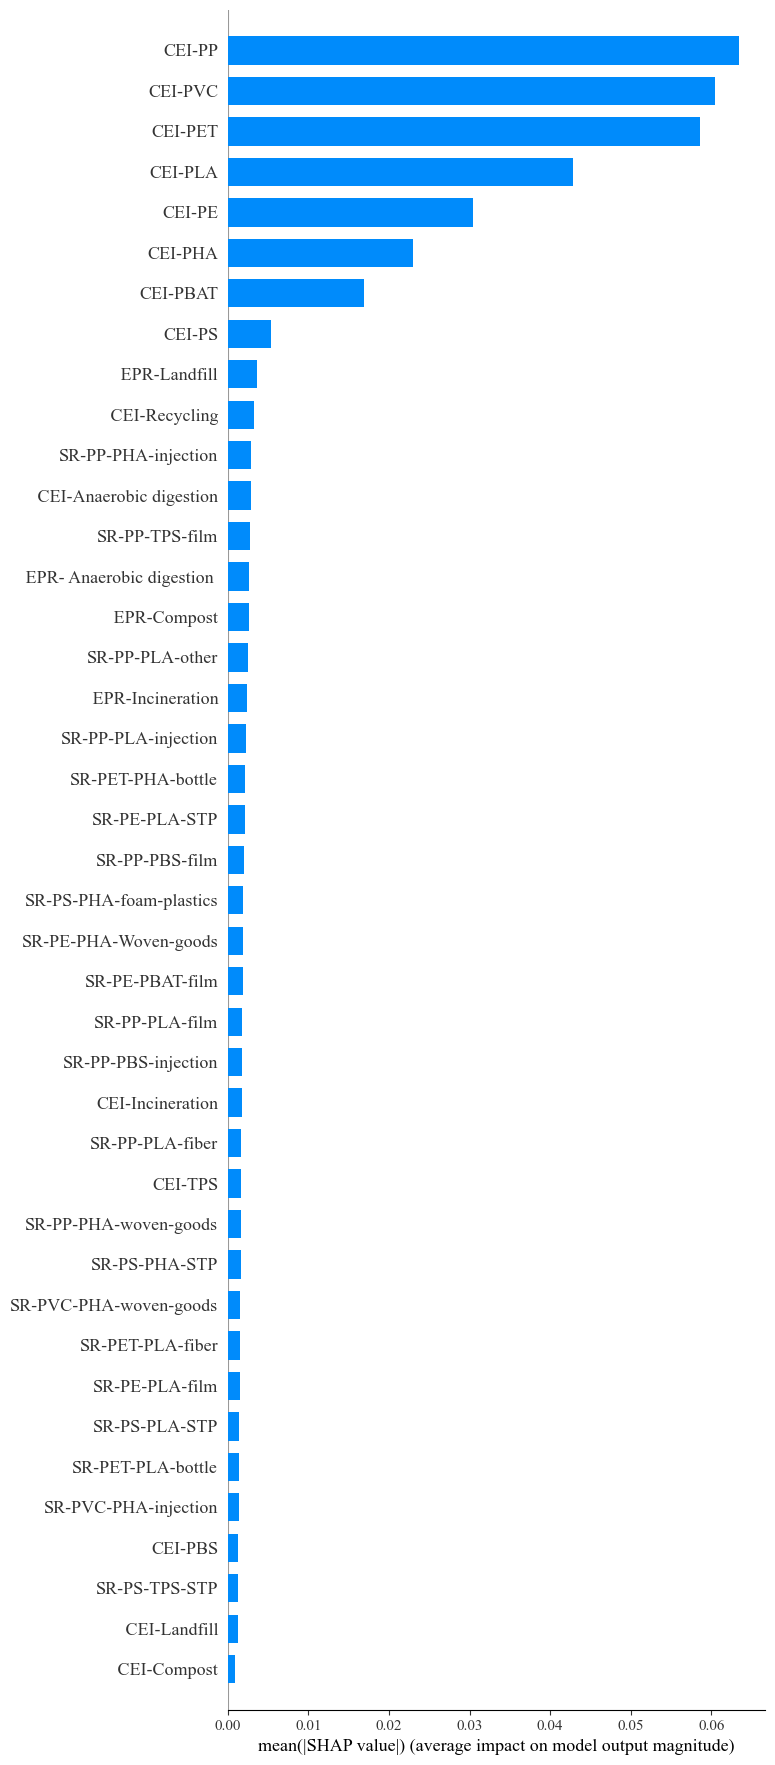

In [24]:
shap.summary_plot(shap_values, X_test,plot_type='bar',max_display=150)

In [21]:
feature_importance = pd.DataFrame()

feature_importance['feature'] = feature_names

feature_importance['importance'] = np.abs(shap_values).mean(0)

feature_importance.sort_values('importance', ascending=False)

,feature,importance
32,CEI-PP,0.063475
34,CEI-PVC,0.060500
31,CEI-PET,0.058525
29,CEI-PLA,0.042765
35,CEI-PE,0.030415
28,CEI-PHA,0.022980
27,CEI-PBAT,0.016933
33,CEI-PS,0.005314
25,EPR-Landfill,0.003647
38,CEI-Recycling,0.003306


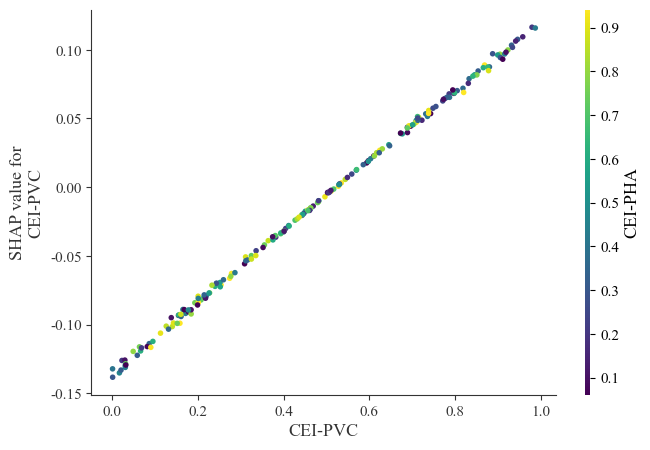

In [31]:
#设置字体和大小
plt.rcParams['font.family']='serif'
plt.rcParams['font.serif']= 'Times New Roman'
plt.rcParams['font.size']=13

shap.dependence_plot('CEI-PVC',shap_values, X_test, interaction_index='CEI-PHA',cmap='viridis')